In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch_TST.model.TST import PatchTST_backbone,TSL
from torch_TST.model.TSM import TSM
from torch_TST.model.LSTM import LSTM
from torch_TST.model.Transformer import TF
from torch_TST.model.GRU import GRU
from torch.utils.data import Dataset, DataLoader
from torch_TST.layer.utils import *
from torch_TST.layer.data_get import *
from torch.optim import Adam
from tqdm.auto import tqdm
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
data_features_dict = {
    "ELBSL4-12570S机组系统_L4-125S压缩机组_01#压缩机_压缩机1能级状态": "cpr1",
    "ELBSL4-12570S机组系统_L4-125S压缩机组_02#压缩机_压缩机2能级状态": "cpr2",
    "ELBSL4-12570S机组系统_L4-125S压缩机组_03#压缩机_压缩机3能级状态": "cpr3",
    "ELBSL4-12570S机组系统_L4-70S压缩机组_04#压缩机_压缩机4能级状态": "cpr4",
    "ELBSL4-12570S机组系统_L4冷凝设备组_01#水泵_蒸发冷水泵": "cdr_pump",
    "ELBSL4-12570S机组系统_L4冷凝设备组_01#风机_蒸发冷风机1": "cdr_fan1",
    "ELBSL4-12570S机组系统_L4冷凝设备组_02#风机_蒸发冷风机2": "cdr_fan2",
    "ELBSL4-12570S机组系统_L4冷凝设备组_03#风机_蒸发冷风机3": "cdr_fan3",
    "ELBSL4-12570S机组系统_L4-125S压缩机组_冷冻吸气压力": "in_pa",
    "ELBSL4-12570S机组系统_L4-125S压缩机组_冷冻吸气温度": "in_temp",
    "ELBSL4-12570S机组系统_L4-125S压缩机组_排气压力": "ex_pa",
    "ELBSL4-12570S机组系统_L4-125S压缩机组_供液温度": "liq_temp",
    "ELBSL4-12570S机组系统_L4-125S压缩机组_排气温度": "ex_temp",
    "ELBSL4-12570S机组系统_L4-125S压缩机组_环境温度": "env_temp",
    "3#冷冻库_01#风机_风机状态": "fre3_fan1",
    "冷藏库_01#风机_风机状态": "refr_fan",
    "1#冷冻库_01#风机_风机状态": "fre1_fan1",
    "2#冷冻库_01#风机_风机状态": "fre2_fan1",
    "3#冷冻库_02#风机_风机状态": "fre3_fan2",
    "冷藏库_02#风机_风机状态": "refr_fan2",
    "1#冷冻库_02#风机_风机状态": "fre1_fan2",
    "2#冷冻库_02#风机_风机状态": "fre2_fan2",
    "月台_01#02#风机_风机状态": "pf_fan12",
    "1#冷冻库_03#风机_风机状态": "fre1_fan3",
    "2#冷冻库_03#风机_风机状态": "fre2_fan3",
    "3#冷冻库_03#风机_风机状态": "fre3_fan3",
    "月台_03#04#风机_风机状态": "pf_fan34",
    "3#冷冻库_04#风机_风机状态": "fre3_fan4",
    "1#冷冻库_04#风机_风机状态": "fre1_fan4",
    "2#冷冻库_04#风机_风机状态": "fre2_fan4",
    "1#冷冻库_05#风机_风机状态": "fre1_fan5",
    "月台_05#06#风机_风机状态": "pf_fan56",
    "1#冷冻库_06#风机_风机状态": "fre1_fan6",
    "1#冷冻库_冷冻1_传感器1温度": "fre1_temp1",
    "1#冷冻库_冷冻1_传感器2温度": "fre1_temp2",
    "1#冷冻库_冷冻1_传感器3温度": "fre1_temp3",
    "1#冷冻库_冷冻1_传感器4温度": "fre1_temp4",
    "1#冷冻库_冷冻1_传感器5温度": "fre1_temp5",
    "1#冷冻库_冷冻1_传感器6温度": "fre1_temp6",
    "1#冷冻库_冷冻1_平均温度": "fre1_temp_avg",
    "2#冷冻库_冷冻库2门1_冷冻库2门1": "fre2_door1",
    "2#冷冻库_冷冻库2门2_冷冻库2门2": "fre2_door2",
    "2#冷冻库_冷冻库2门3_冷冻库2门3": "fre2_door3",
    "2#冷冻库_冷冻2_传感器1温度": "fre2_temp1",
    "2#冷冻库_冷冻2_传感器2温度": "fre2_temp2",
    "2#冷冻库_冷冻2_传感器3温度": "fre2_temp3",
    "2#冷冻库_冷冻2_传感器4温度": "fre2_temp4",
    "2#冷冻库_冷冻2_平均温度": "fre2_temp_avg",
    "3#冷冻库_冷冻3_传感器1温度": "fre3_temp1",
    "3#冷冻库_冷冻3_传感器2温度": "fre3_temp2",
    "3#冷冻库_冷冻3_传感器3温度": "fre3_temp3",
    "3#冷冻库_冷冻3_传感器4温度": "fre3_temp4",
    "3#冷冻库_冷冻3_平均温度": "fre3_temp_avg",
    "ELBSL4-12570S机组系统_其他_L4机组电表_L4机组_Psum": "kw",
    "1#冷冻库_冷冻1_温度设定上限": "fre1_temp_up",
    "1#冷冻库_冷冻1_温度设定下限": "fre1_temp_low",
    "2#冷冻库_冷冻2_温度设定上限": "fre2_temp_up",
    "2#冷冻库_冷冻2_温度设定下限": "fre2_temp_low",
    "3#冷冻库_冷冻3_温度设定上限": "fre3_temp_up",
    "3#冷冻库_冷冻3_温度设定下限": "fre3_temp_low"
}
features = [
    'ELBSL4-12570S机组系统_其他_L4机组电表_L4机组_Psum',
    'ELBSL4-12570S机组系统_L4冷凝设备组_01#水泵_蒸发冷水泵',
    'ELBSL4-12570S机组系统_L4冷凝设备组_01#风机_蒸发冷风机1',
    '1#冷冻库_05#风机_风机状态',
    'ELBSL4-12570S机组系统_L4-125S压缩机组_03#压缩机_压缩机3能级状态',
    'ELBSL4-12570S机组系统_L4-125S压缩机组_01#压缩机_压缩机1能级状态',
    '1#冷冻库_03#风机_风机状态',
    'ELBSL4-12570S机组系统_L4-125S压缩机组_02#压缩机_压缩机2能级状态',
]
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
features_code =[]
for feature in features: # 特征的字母表示
    features_code.append(data_features_dict[feature])
df = pd.read_csv(r"..\data\data_wh1_1hour.csv", index_col=0, parse_dates=['time'])
def add_time_features(df):
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['day_of_month'] = df.index.day
    df['month'] = df.index.month
    return df
features_code.append('hour')
features_code.append('day_of_week')
features_code.append('day_of_month')
features_code.append('month')
df = add_time_features(df)

In [2]:
input_len = 14*24
output_len  = 7*24
c_in = df.shape[1]
train_loader,test_loader = give_me_dataloader(df,input_len,output_len)

In [26]:
train_loader,test_loader = give_me_wavelet_dataloader(df,input_len,output_len)

E:\Deeplearn\TS\torch_TST\layer\data_get.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kw'].iloc[i] = kw_denoised[i]
E:\Deeplearn\TS\torch_TST\layer\data_get.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kw'].iloc[i] = kw_denoised[i]
E:\Deeplearn\TS\torch_TST\layer\data_get.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kw'].iloc[i] = kw_denoised[i]
E:\Deeplearn\TS\torch_TST\layer\data_get.py:31: Setting

In [3]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fct=None):
    """
    default with mape
    return one scalar
    """
    loss_list = []
    # perdict_list = []
    for x,labes in dataloader:
        x = x.to(device)
        labes = labes.to(device)
        perdicts = model(x).to(device)
        if loss_fct is not None:
            loss = loss_fct(perdicts,labes)         # 验证集损失
        else:
            loss = mape_loss(perdicts,labes)
        loss_list.append(loss.cpu().item())
        # labels_1d = labes.view(-1)
        # perdict = perdicts[:,0,:]
        # p = perdict.view(-1)
        # perdict_list.append(p.cpu().item())

    return np.mean(loss_list)
    # return loss_list


In [4]:
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    scheduler=None,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }
    global_step = 1
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for x,y in train_loader:
                x = x.to(device)
                y = y.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 前向计算
                pedicts = model(x)
                loss = loss_fct(pedicts,y)
                # 梯度回传
                loss.backward()
                # 调整优化器，包括学习率的变动等
                optimizer.step()
                if scheduler is not None:
                    scheduler.step() # 更新学习率
                loss = loss.cpu().item()
                # record
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })

                # evaluating
                if global_step % eval_step == 0:
                    # model.eval()
                    # val_loss = evaluating(model, val_loader, loss_fct)
                    # record_dict["val"].append({
                    #     "loss": val_loss, "step": global_step
                    # })
                    # model.train()

                    # 1. 使用 tensorboard 可视化
                    # cur_lr = optimizer.param_groups[0]["lr"] if scheduler is None else scheduler.get_last_lr()[0]
                    # if tensorboard_callback is not None:
                    #     tensorboard_callback(
                    #         global_step,
                    #         loss=loss, val_loss=val_loss,
                    #         lr=cur_lr,
                    #         )
                    #
                    # # 2. 保存模型权重 save model checkpoint
                    # if save_ckpt_callback is not None:
                    #     save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(-loss)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # udate step
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})

    return record_dict

In [ ]:
model = TSM(c_in=c_in,input_len=input_len,output_len=output_len,MLP_hd=[32,64,32,16],output_dim=1).to(device)

In [27]:
model = TSL(c_in=c_in,input_len=input_len,output_len=output_len).to(device)

In [28]:
early_stop = EarlyStopCallback()
optimizer = Adam(params=model.parameters(), lr=1e-5, weight_decay=5e-3, eps=5e-9)
loss_f = nn.MSELoss()

In [29]:
record = training(model=model,train_loader=train_loader,val_loader=test_loader,
                  epoch=40,loss_fct=loss_f,optimizer=optimizer) 

  0%|          | 0/7800 [00:00<?, ?it/s]

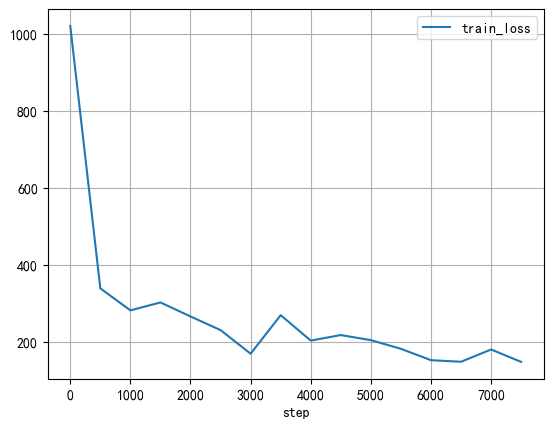

In [30]:
plot_learning_curves(record)

In [31]:
model.eval()
loss = evaluating(model, test_loader,mape_loss)
print(f"loss:     {loss:.4f}")  

loss:     23.8378


In [32]:
model.eval()
loss = evaluating(model, test_loader,loss_f)
print(f"loss:     {loss:.4f}")

loss:     1779.0758
